In [1]:
import torch
import torch.nn as nn

import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pickle

from torch.utils.data import DataLoader, Dataset, random_split, ConcatDataset

if torch.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

device

(null): No such file or directory
(null): No such file or directory


device(type='cuda')

In [2]:
from model import CodyConvNet
import utils as ut
import dataset

In [3]:
classes = ["airplane", "bird", "car", "cat", "deer", "dog", "horse", "monkey", "ship", "truck"]

In [4]:
trainset, valset, testset = dataset.get_datasets()

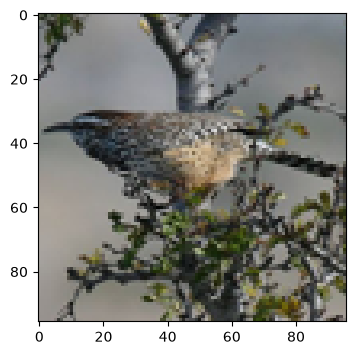

In [5]:
IDX = 32
img, label = valset[IDX]
ut.imshow(img)

In [6]:
### -- HARDCODED PARAMETERS -- ###
image_dim = trainset[0][0].shape[1]
batch_size = 64
n_epochs = 300

parameters = {
    "lr" : 0.0005,
    "weight_decay" : 1e-3,
    "cnr" : 1,
    "dnr" : 1,
    "dropout" : 0.5,
    "dropout2d" : 0.2,
}
### --------- ###

In [7]:
try:
    with open("best_params.pkl", "rb") as f:
        parameters = pickle.load(f)
    print("best_params.pkl file successfully loaded.")

except FileNotFoundError:
    pass

for key, value in parameters.items():
    print(f"   - {key}: {value}")

best_params.pkl file successfully loaded.
   - learning_rate: 0.0002050164810203737
   - weight_decay: 0.006258196814907232
   - cnr: 4
   - dnr: 1
   - dropout: 0.15986459731150085
   - dropout2d: 0.2653223538119807


In [8]:
model = CodyConvNet(
    image_dim=image_dim, 
    n_classes=len(classes),
    conv_neuron_rate=parameters["cnr"],
    dense_neuron_rate=parameters["dnr"],
    dropout=parameters["dropout"],
    dropout2d=parameters["dropout2d"]
)

model.to(device)
optim = torch.optim.AdamW(model.parameters(), lr=parameters["learning_rate"], weight_decay=parameters["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, factor=0.6, patience=10)
loss_function = nn.CrossEntropyLoss().to(device)

train_loader, valid_loader, test_loader = dataset.get_dataloaders(train=trainset, val=valset, test=testset, 
    batch_size=batch_size)

In [9]:
type(optim)

torch.optim.adamw.AdamW

In [ ]:
history = ut.train(model=model, optimizer=optim, criterion=loss_function, train_loader=train_loader, valid_loader=valid_loader, n_epochs=n_epochs, scheduler=scheduler)

Epoch 1/300 | LR: 2.05e-04 | Train EntropyLoss: 1.5982e+00 (Acc: 40.1%) | Valid EntropyLoss: 1.7905e+00 (Acc: 41.5%)
Epoch 2/300 | LR: 2.05e-04 | Train EntropyLoss: 1.3134e+00 (Acc: 51.9%) | Valid EntropyLoss: 1.3269e+00 (Acc: 51.8%)
Epoch 3/300 | LR: 2.05e-04 | Train EntropyLoss: 1.1853e+00 (Acc: 56.8%) | Valid EntropyLoss: 1.2292e+00 (Acc: 57.3%)
Epoch 4/300 | LR: 2.05e-04 | Train EntropyLoss: 1.0963e+00 (Acc: 59.7%) | Valid EntropyLoss: 1.0496e+00 (Acc: 61.7%)
Epoch 5/300 | LR: 2.05e-04 | Train EntropyLoss: 1.0290e+00 (Acc: 62.5%) | Valid EntropyLoss: 1.0078e+00 (Acc: 66.6%)
Epoch 6/300 | LR: 2.05e-04 | Train EntropyLoss: 9.6026e-01 (Acc: 65.1%) | Valid EntropyLoss: 1.0190e+00 (Acc: 66.0%)
Epoch 7/300 | LR: 2.05e-04 | Train EntropyLoss: 9.2602e-01 (Acc: 66.7%) | Valid EntropyLoss: 9.6970e-01 (Acc: 66.0%)
Epoch 8/300 | LR: 2.05e-04 | Train EntropyLoss: 8.8875e-01 (Acc: 68.0%) | Valid EntropyLoss: 1.0223e+00 (Acc: 65.3%)
Epoch 9/300 | LR: 2.05e-04 | Train EntropyLoss: 8.4648e-01 (Acc:

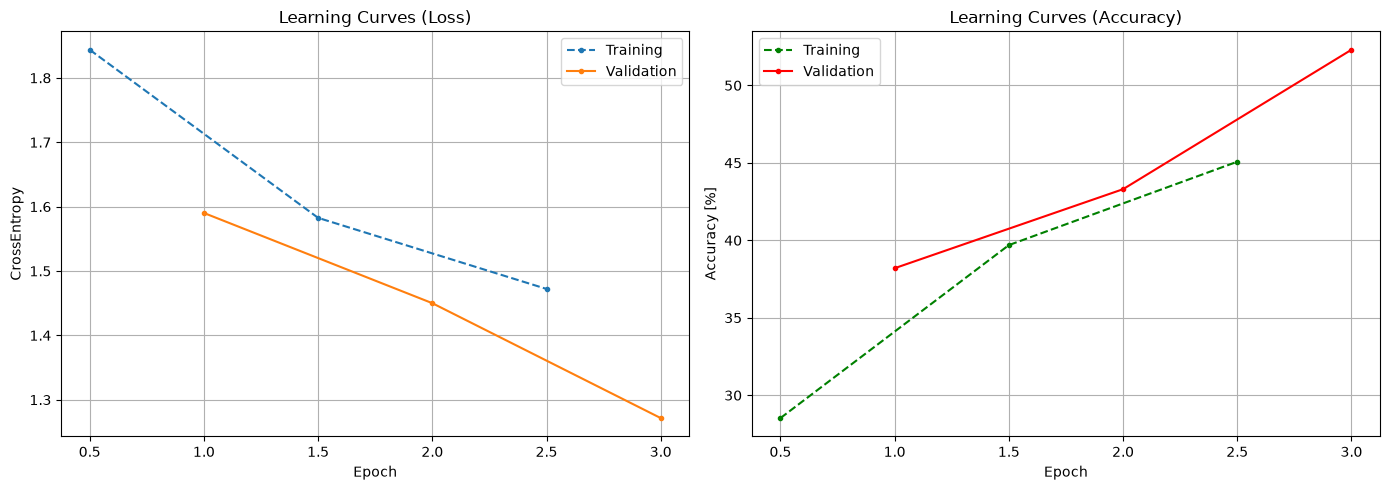

In [ ]:
ut.plot_training(history)

In [ ]:
save_path = f"cody_cnn_optuned.pth"
torch.save(model, save_path)

In [ ]:
train_true, train_preds = ut.evaluate_model(model, train_loader, device, classes, "Training set")
val_true, val_preds = ut.evaluate_model(model, valid_loader, device, classes, "Validation set")

# 2. Sprawdzamy ostateczny zbiór testowy (8000 zdjęć, których model NIGDY nie widział)
train_true, train_preds = ut.evaluate_model(model, test_loader, device, classes, "Test set")


--- Evaluating dataset: Training set ---
Accuracy: 52.45%

Specified report:
              precision    recall  f1-score   support

    airplane       0.76      0.69      0.72      1090
        bird       0.62      0.29      0.39      1083
         car       0.67      0.74      0.70      1104
         cat       0.38      0.43      0.41      1107
        deer       0.50      0.40      0.45      1096
         dog       0.30      0.31      0.30      1115
       horse       0.74      0.41      0.53      1097
      monkey       0.35      0.72      0.48      1098
        ship       0.65      0.78      0.71      1105
       truck       0.62      0.48      0.54      1105

    accuracy                           0.52     11000
   macro avg       0.56      0.52      0.52     11000
weighted avg       0.56      0.52      0.52     11000


--- Evaluating dataset: Validation set ---
Accuracy: 52.30%

Specified report:
              precision    recall  f1-score   support

    airplane       0.72     

KeyboardInterrupt: 


--- Evaluating dataset: Validation set ---


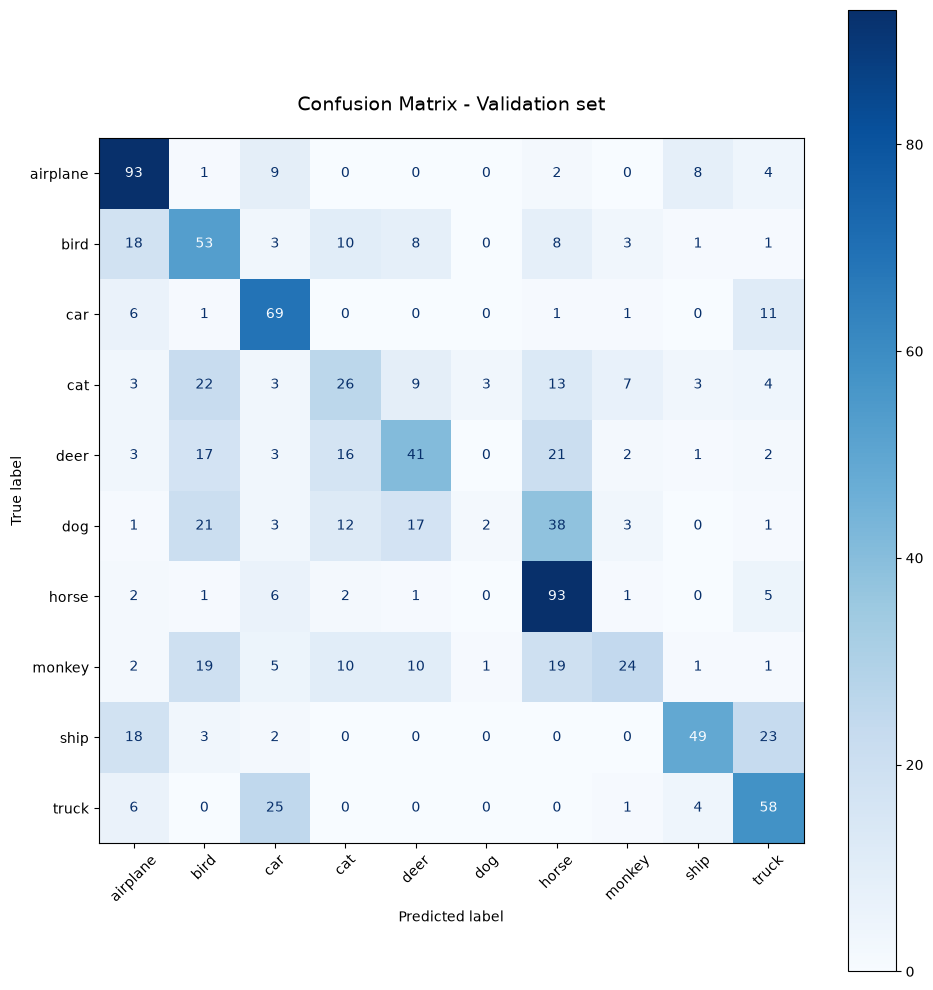

In [ ]:
ut.plot_cm(model, valid_loader, classes)

In [ ]:
ut.evaluate(model, valid_loader, loss_function)

(1.4029655456542969, 0.508)

In [ ]:
path = "cody_cnn.pth"
model = torch.load(path, weights_only=False)
model.eval()

CodyConvNet(
  (model): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, b

Losowanie nowych zdjęć ze zbioru i generowanie predykcji...


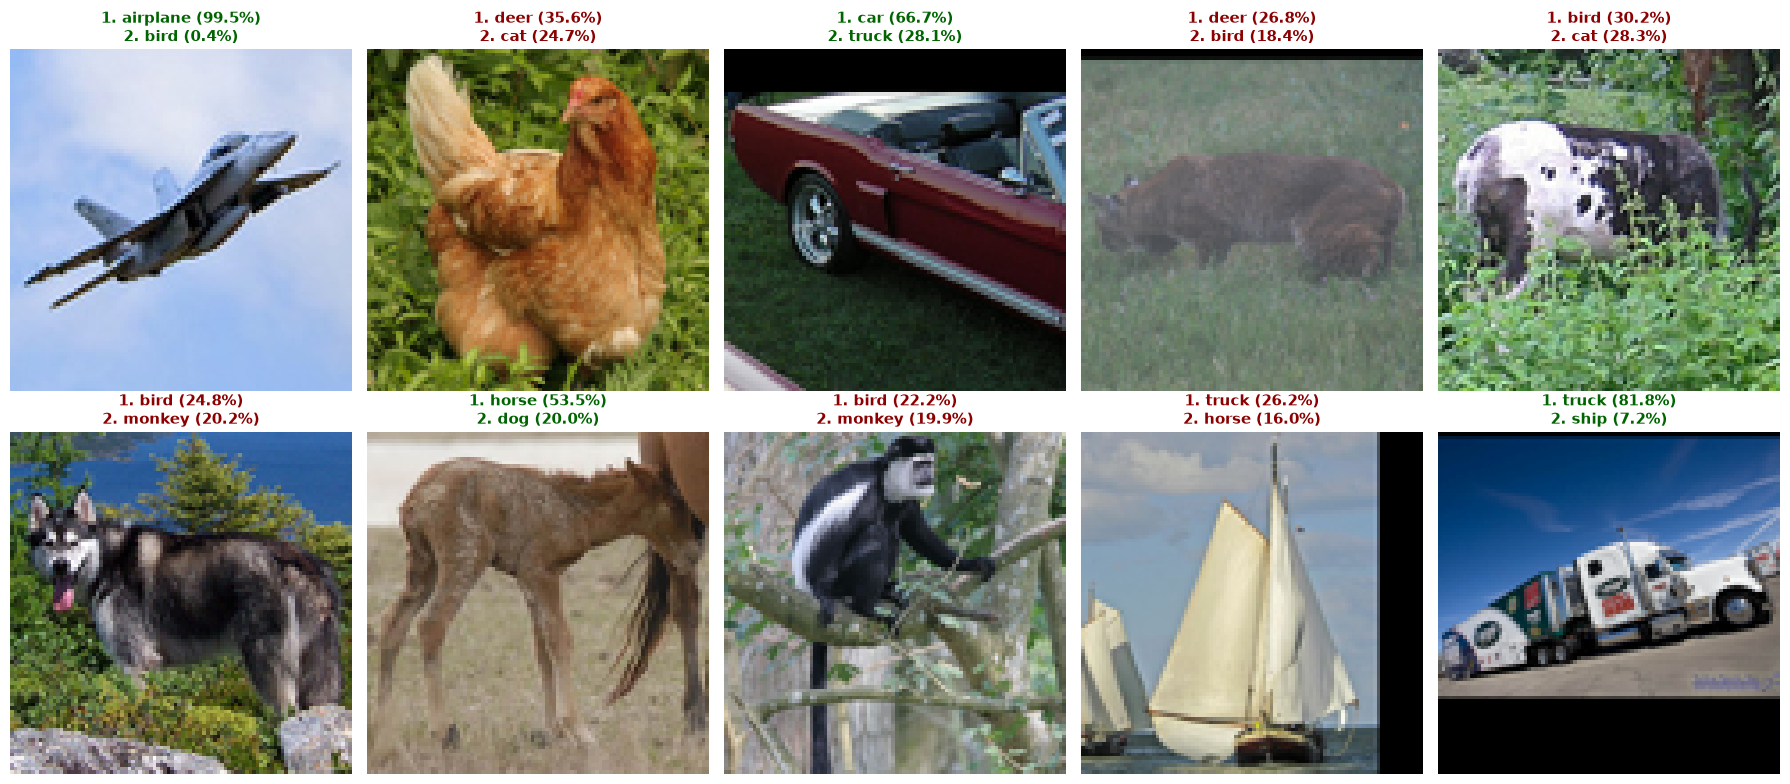

In [ ]:
ut.visualize_random_top2_predictions(model, valid_loader, device, classes)